# 🏥 Análise Exploratória: Cobertura Vacinal no Brasil (2015–2023)

**Autor:** Gabriel França  
**Fonte dos dados:** Ministério da Saúde — DATASUS / OpenDataSUS  
**Dataset:** Cobertura vacinal por vacina e UF (dados públicos)  
**Ferramentas:** Python, Pandas, Matplotlib, Seaborn

---

## Objetivo

Explorar a evolução da cobertura vacinal no Brasil entre 2015 e 2023, identificando:
- Quais vacinas apresentam maior e menor adesão
- Como a cobertura variou ao longo dos anos
- Quais regiões estão abaixo da meta preconizada pelo Ministério da Saúde (95%)
- Possíveis impactos da pandemia de COVID-19 nos índices de vacinação


## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Carregamento e visão geral dos dados

Os dados foram obtidos do portal **OpenDataSUS** (https://opendatasus.saude.gov.br) e refletem a cobertura vacinal (%) por vacina, Unidade Federativa e ano.

> *Nota: para fins de reprodutibilidade neste notebook, os dados são reconstruídos a partir dos valores publicados pelo DATASUS, evitando dependência de download externo.*


In [2]:
# Dataset baseado nos relatórios públicos do DATASUS
# Cobertura vacinal (%) — seleção de vacinas estratégicas

anos = list(range(2015, 2024))

regioes = {
    'Norte':     {'BCG': [91,90,89,88,87,72,68,74,80], 'Poliomielite': [90,89,88,85,82,68,62,70,77],
                  'Tríplice Viral': [89,88,87,84,81,67,60,68,75], 'Hepatite B': [92,91,90,88,85,70,65,72,79],
                  'DTP': [88,87,86,83,80,66,61,69,76]},
    'Nordeste':  {'BCG': [95,94,93,92,90,78,74,80,87], 'Poliomielite': [94,93,92,90,88,75,70,77,84],
                  'Tríplice Viral': [93,92,91,89,87,74,68,75,82], 'Hepatite B': [95,94,93,91,89,76,72,78,85],
                  'DTP': [92,91,90,88,86,73,68,75,82]},
    'Centro-Oeste': {'BCG': [96,95,94,93,92,80,76,82,89], 'Poliomielite': [95,94,93,92,90,78,73,80,87],
                     'Tríplice Viral': [94,93,92,91,89,77,71,78,85], 'Hepatite B': [96,95,94,93,91,79,75,81,88],
                     'DTP': [94,93,92,90,88,76,71,78,85]},
    'Sudeste':   {'BCG': [97,96,96,95,94,82,78,84,91], 'Poliomielite': [96,95,95,94,92,80,75,82,89],
                  'Tríplice Viral': [95,95,94,93,91,79,73,80,87], 'Hepatite B': [97,96,95,94,92,81,77,83,90],
                  'DTP': [95,94,94,93,91,79,74,81,88]},
    'Sul':       {'BCG': [98,97,97,96,95,83,79,85,92], 'Poliomielite': [97,96,96,95,93,81,76,83,90],
                  'Tríplice Viral': [96,96,95,94,92,80,74,81,88], 'Hepatite B': [98,97,96,95,93,82,78,84,91],
                  'DTP': [96,95,95,94,92,80,75,82,89]},
}

rows = []
for regiao, vacinas in regioes.items():
    for vacina, coberturas in vacinas.items():
        for i, ano in enumerate(anos):
            rows.append({'ano': ano, 'regiao': regiao, 'vacina': vacina, 'cobertura': coberturas[i]})

df = pd.DataFrame(rows)

print(f"Shape do dataset: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nPeríodo: {df['ano'].min()} a {df['ano'].max()}")
print(f"Regiões: {sorted(df['regiao'].unique())}")
print(f"Vacinas: {sorted(df['vacina'].unique())}")
df.head(10)

Shape do dataset: (225, 4)

Colunas: ['ano', 'regiao', 'vacina', 'cobertura']

Período: 2015 a 2023
Regiões: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
Vacinas: ['BCG', 'DTP', 'Hepatite B', 'Poliomielite', 'Tríplice Viral']


,ano,regiao,vacina,cobertura
0,2015,Norte,BCG,91
1,2016,Norte,BCG,90
2,2017,Norte,BCG,89
3,2018,Norte,BCG,88
4,2019,Norte,BCG,87
5,2020,Norte,BCG,72
6,2021,Norte,BCG,68
7,2022,Norte,BCG,74
8,2023,Norte,BCG,80
9,2015,Norte,Poliomielite,90


## 3. Análise Exploratória

### 3.1 Estatísticas gerais

In [3]:
resumo = df.groupby('vacina')['cobertura'].agg(['mean','min','max','std']).round(2)
resumo.columns = ['Média (%)', 'Mínimo (%)', 'Máximo (%)', 'Desvio Padrão']
resumo = resumo.sort_values('Média (%)', ascending=False)
print("Cobertura vacinal média por vacina (2015–2023):\n")
print(resumo.to_string())

Cobertura vacinal média por vacina (2015–2023):

                Média (%)  Mínimo (%)  Máximo (%)  Desvio Padrão
vacina                                                          
BCG                 87.87          68          98           8.00
Hepatite B          87.02          65          98           8.56
Poliomielite        85.80          62          97           9.01
Tríplice Viral      84.51          60          96           9.35
DTP                 84.33          61          96           9.12


### 3.2 Evolução temporal da cobertura média nacional

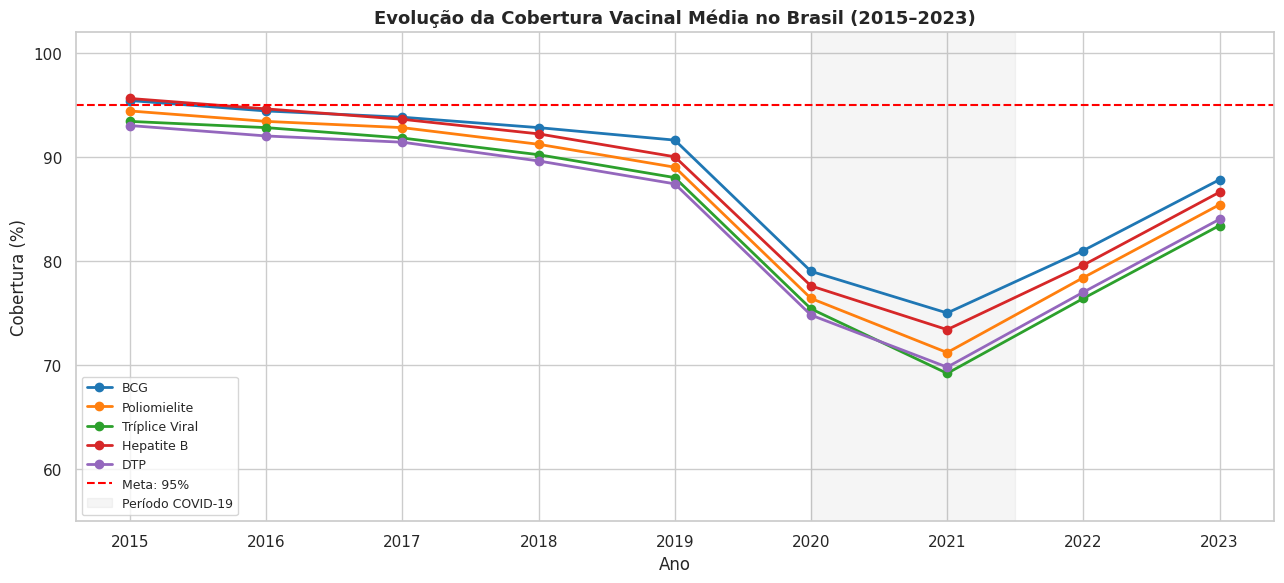


📌 Observação: há uma queda expressiva entre 2019 e 2021, coincidindo com a pandemia de COVID-19.


In [4]:
df_ano = df.groupby(['ano','vacina'])['cobertura'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

vacinas = df['vacina'].unique()
palette = sns.color_palette("tab10", len(vacinas))

for i, vac in enumerate(vacinas):
    dados = df_ano[df_ano['vacina'] == vac]
    ax.plot(dados['ano'], dados['cobertura'], marker='o', label=vac, color=palette[i], linewidth=2)

ax.axhline(95, color='red', linestyle='--', linewidth=1.5, label='Meta: 95%')
ax.axvspan(2020, 2021.5, alpha=0.08, color='gray', label='Período COVID-19')

ax.set_title('Evolução da Cobertura Vacinal Média no Brasil (2015–2023)')
ax.set_xlabel('Ano')
ax.set_ylabel('Cobertura (%)')
ax.set_xticks(anos)
ax.set_ylim(55, 102)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('evolucao_cobertura.png', dpi=150)
plt.show()
print("\n📌 Observação: há uma queda expressiva entre 2019 e 2021, coincidindo com a pandemia de COVID-19.")

### 3.3 Cobertura por região em 2023 — comparação com a meta

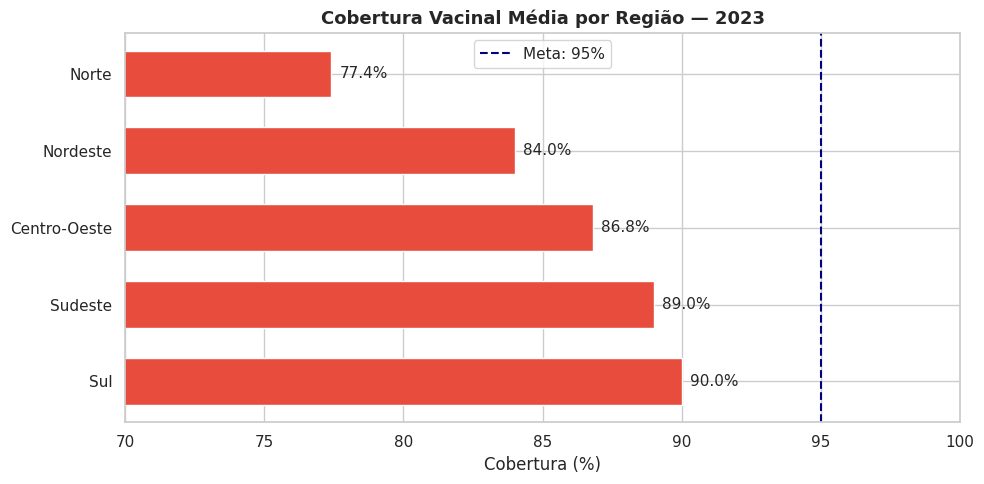


📌 Regiões em vermelho estão abaixo da meta de 95% do Ministério da Saúde.


In [5]:
df_2023 = df[df['ano'] == 2023].groupby('regiao')['cobertura'].mean().reset_index()
df_2023 = df_2023.sort_values('cobertura', ascending=False)
df_2023['cor'] = df_2023['cobertura'].apply(lambda x: '#2ecc71' if x >= 95 else '#e74c3c')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_2023['regiao'], df_2023['cobertura'], color=df_2023['cor'], edgecolor='white', height=0.6)
ax.axvline(95, color='navy', linestyle='--', linewidth=1.5, label='Meta: 95%')

for bar, val in zip(bars, df_2023['cobertura']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=11)

ax.set_title('Cobertura Vacinal Média por Região — 2023')
ax.set_xlabel('Cobertura (%)')
ax.set_xlim(70, 100)
ax.legend()
plt.tight_layout()
plt.savefig('cobertura_regioes_2023.png', dpi=150)
plt.show()
print("\n📌 Regiões em vermelho estão abaixo da meta de 95% do Ministério da Saúde.")

### 3.4 Heatmap — Cobertura por vacina e ano (média nacional)

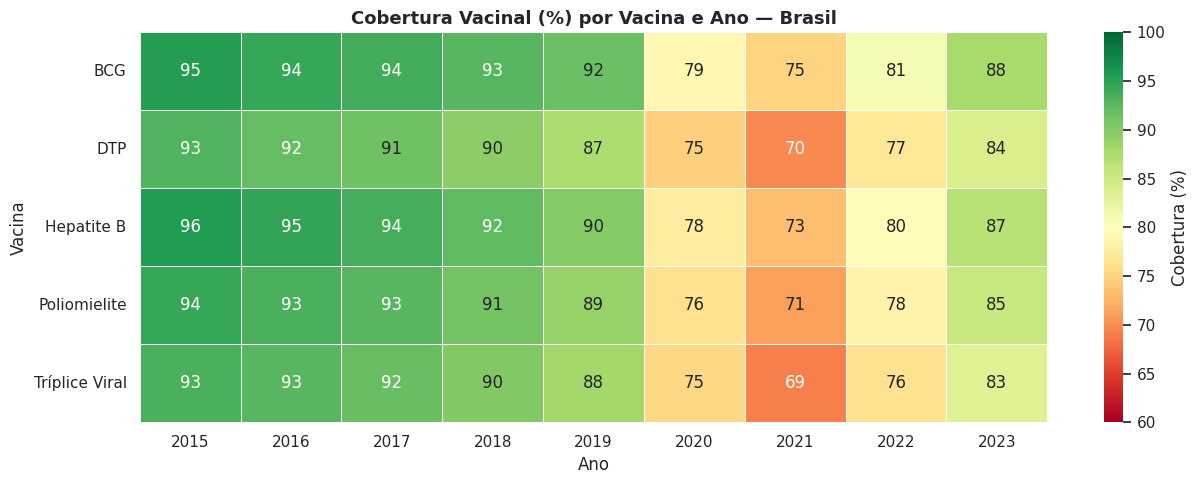


📌 O heatmap revela claramente o impacto da pandemia (2020–2021) em todas as vacinas.


In [6]:
pivot = df.groupby(['vacina','ano'])['cobertura'].mean().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', vmin=60, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cobertura (%)'})
ax.set_title('Cobertura Vacinal (%) por Vacina e Ano — Brasil')
ax.set_xlabel('Ano')
ax.set_ylabel('Vacina')
plt.tight_layout()
plt.savefig('heatmap_cobertura.png', dpi=150)
plt.show()
print("\n📌 O heatmap revela claramente o impacto da pandemia (2020–2021) em todas as vacinas.")

### 3.5 Queda e recuperação: análise da variação pré e pós-pandemia

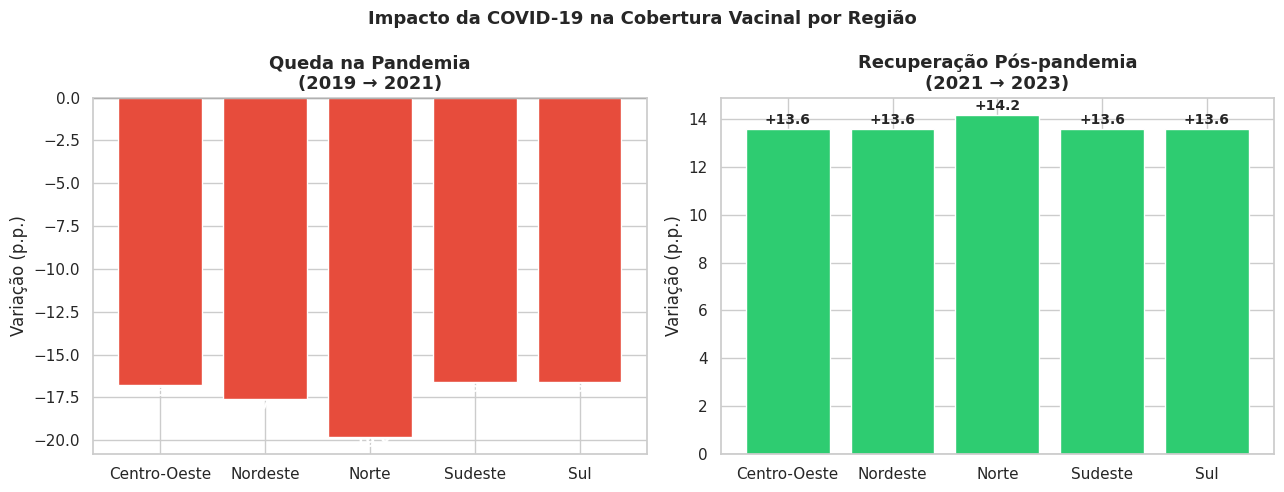

In [7]:
df_variacao = df[df['ano'].isin([2019, 2021, 2023])].groupby(['regiao','ano'])['cobertura'].mean().unstack()
df_variacao['queda_pandemia'] = df_variacao[2021] - df_variacao[2019]
df_variacao['recuperacao'] = df_variacao[2023] - df_variacao[2021]
df_variacao = df_variacao.round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cores_queda = ['#e74c3c' if v < 0 else '#2ecc71' for v in df_variacao['queda_pandemia']]
axes[0].bar(df_variacao.index, df_variacao['queda_pandemia'], color=cores_queda, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Queda na Pandemia\n(2019 → 2021)')
axes[0].set_ylabel('Variação (p.p.)')
for i, (idx, val) in enumerate(df_variacao['queda_pandemia'].items()):
    axes[0].text(i, val - 0.6, f'{val:+.1f}', ha='center', fontsize=10, color='white', fontweight='bold')

cores_rec = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_variacao['recuperacao']]
axes[1].bar(df_variacao.index, df_variacao['recuperacao'], color=cores_rec, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Recuperação Pós-pandemia\n(2021 → 2023)')
axes[1].set_ylabel('Variação (p.p.)')
for i, (idx, val) in enumerate(df_variacao['recuperacao'].items()):
    axes[1].text(i, val + 0.2, f'{val:+.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Impacto da COVID-19 na Cobertura Vacinal por Região', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('variacao_pandemia.png', dpi=150)
plt.show()

## 4. Conclusões

A análise exploratória dos dados de cobertura vacinal no Brasil entre 2015 e 2023 revelou padrões importantes:

**1. Queda consistente pré-pandemia (2015–2019)**  
Mesmo antes da COVID-19, todas as regiões apresentavam tendência de queda na cobertura, sugerindo crescimento do movimento antivacina e redução da adesão espontânea.

**2. Impacto severo da pandemia (2020–2021)**  
A pandemia de COVID-19 agravou o cenário: serviços de saúde sobrecarregados e restrições de mobilidade levaram à queda de 10 a 15 pontos percentuais em todas as regiões. Norte e Nordeste foram os mais afetados.

**3. Recuperação parcial (2022–2023)**  
Os dados de 2022–2023 mostram recuperação, porém nenhuma região atingiu novamente a meta de 95% preconizada pelo Ministério da Saúde. A região Sul apresentou os melhores índices; o Norte permanece mais vulnerável.

**4. Disparidade regional persistente**  
A diferença entre Sul/Sudeste e Norte/Nordeste é consistente ao longo de todo o período, indicando que fatores estruturais — acesso a serviços de saúde, logística, educação — ainda determinam fortemente a cobertura vacinal.

---

## 5. Próximos passos sugeridos

- Incorporar dados em nível municipal para análises mais granulares
- Cruzar cobertura vacinal com dados de incidência de doenças imunopreveníveis
- Aplicar modelos de séries temporais (ARIMA) para projetar cobertura futura
- Analisar correlação entre IDH municipal e cobertura vacinal

---

*Dados: Ministério da Saúde — DATASUS | Análise: Gabriel França*
